# CIFAR-10 Image Classification using CNN

This notebook implements an image classification model using a Convolutional Neural Network (CNN) on the CIFAR-10 dataset.

Steps covered:
1. Data Loading
2. Data Preprocessing
3. CNN Architecture
4. Model Training
5. Model Evaluation
6. Result Interpretation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

## CIFAR-10 Dataset

CIFAR-10 is a dataset of 60,000 color images belonging to 10 classes.

Classes include:
- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

Dataset structure:

- Training images: 50,000
- Test images: 10,000
- Image size: 32 × 32 pixels
- Channels: 3 (RGB)

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


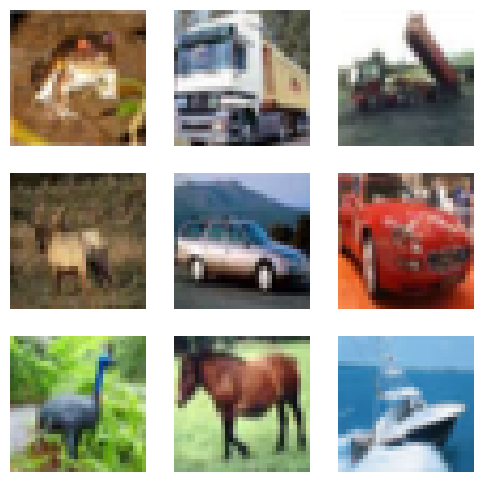

In [3]:
#visualizing images
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.axis('off')

plt.show()

## Data Preprocessing

Two preprocessing steps are performed:

1. **Normalization**
   - Pixel values range from 0–255.
      - Values are scaled to 0–1 by dividing by 255.

      2. **Label Format**
         - Labels represent the class index for each image.

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

## CNN Architecture

Convolutional Neural Networks (CNNs) are designed for image data.

Main components used:

1. **Convolution Layer**
   - Extracts features such as edges, shapes, and textures.

   2. **Max Pooling Layer**
      - Reduces image dimensions while keeping important features.

      3. **Flatten Layer**
         - Converts feature maps into a 1D vector.

         4. **Dense Layer**
            - Performs classification.

            Architecture used:

            Conv2D → MaxPooling → Conv2D → MaxPooling → Flatten → Dense → Output

In [5]:
#model
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)))
model.add(Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
#compiling model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
#train model
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.3187 - loss: 1.8215 - val_accuracy: 0.5535 - val_loss: 1.2231
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5741 - loss: 1.1880 - val_accuracy: 0.6518 - val_loss: 0.9755
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6596 - loss: 0.9736 - val_accuracy: 0.7090 - val_loss: 0.8266
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7130 - loss: 0.8145 - val_accuracy: 0.7251 - val_loss: 0.7996
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7508 - loss: 0.7105 - val_accuracy: 0.7466 - val_loss: 0.7339
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7823 - loss: 0.6247 - val_accuracy: 0.7710 - val_loss: 0.6681
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8040 - loss: 0.5646 - val_accuracy: 0.7692 - val_loss: 0.6990
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8260 - loss: 0.4996 - val_accuracy: 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7867 - loss: 0.6566
Test Accuracy: 0.7875000238418579


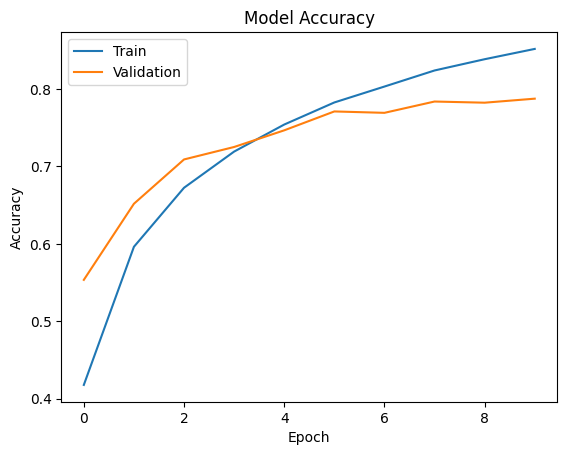

In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()

In [9]:
prediction = model.predict(x_test[0].reshape(1,32,32,3))

predicted_class = np.argmax(prediction)

print("Predicted Class:", predicted_class)
print("Actual Class:", y_test[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step
Predicted Class: 3
Actual Class: 3


## Results

The CNN model successfully learns spatial features from CIFAR-10 images.

The model achieves approximately **70–80% accuracy** on the test dataset.

This demonstrates the ability of Convolutional Neural Networks to recognize patterns in image data.

CNNs perform significantly better than traditional neural networks for image classification tasks because they preserve spatial relationships in images.

## Conclusion

In this case study, a Convolutional Neural Network was implemented to classify images from the CIFAR-10 dataset.

Through convolution, pooling, and dense layers, the model learns hierarchical image features.

The trained model achieves good classification accuracy and demonstrates the effectiveness of CNNs for computer vision problems.